In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from flonacomldft.utils.io_utils import (
    get_path,
    get_project_path,
    load_pickle_file,
    load_csv_file,
)

from flonacomldft.internal_coordinates import Coordinates_mapping
from flonacomldft.utils.plots import (
    set_plot_sequential_data,
    plot_energy_surface,
    plot_energy_histogram,
)

from flonacomldft.utils.diagnostics import (
    R_hat,
    Target_Log_Prob,
)

from flonacomldft.free_energy_computations import (
    compute_TFP_logratio, compute_deepBAR_logratio,
    compute_TFP, compute_BAR
)

import matplotlib.pylab as pylab

size=16
params = {'legend.fontsize': size,
          'figure.figsize': (15, 5),
         'axes.labelsize': size,
         'axes.titlesize': size,
         'xtick.labelsize': size,
         'ytick.labelsize': size}

pylab.rcParams.update(params)


In [10]:
DFT_DATA_PATH = '/mnt/home/amolina/ceph/ADAPTIVE-DFT'
MLP_DATA_PATH = '/mnt/home/amolina/ceph/ADAPTIVE-MLP'

## 1. Single isomer adaptive

In [26]:
adaptive_dft_path = ['1-adaptive/results_2/results_adaptive_is0_25072550/adaptive_sampling_is0_25072550.pkl', 
                '1-adaptive/results_2/results_adaptive_is1_25072551/adaptive_sampling_is1_25072551.pkl']

#adaptive_mlp_path = ['1-adaptive/results_1/results_adaptive_is0_26262660/adaptive_sampling_is0_26262660.pkl',
#                     '1-adaptive/results_1/results_adaptive_is1_26262664/adaptive_sampling_is1_26262664.pkl']

adaptive_mlp_path = ['4-adaptive-mlp-dft/results_adaptive_is0_27047720/adaptive_sampling_is0_27047720.pkl',
                     '4-adaptive-mlp-dft/results_adaptive_is1_27047750/adaptive_sampling_is1_27047750.pkl']


In [27]:
adaptives_mcmc_dft = [load_pickle_file(adaptive_file, DFT_DATA_PATH) for adaptive_file in adaptive_dft_path]
adaptives_mcmc_mlp = [load_pickle_file(adaptive_file, MLP_DATA_PATH) for adaptive_file in adaptive_mlp_path]

### 1.a Acceptance ratio

In [28]:
accs_dft = [torch.cat(adaptive_mcmc['accs']).mean(dim=1) for adaptive_mcmc in adaptives_mcmc_dft]
accs_mlp = [torch.cat(adaptive_mcmc['accs']).mean(dim=1) for adaptive_mcmc in adaptives_mcmc_mlp]

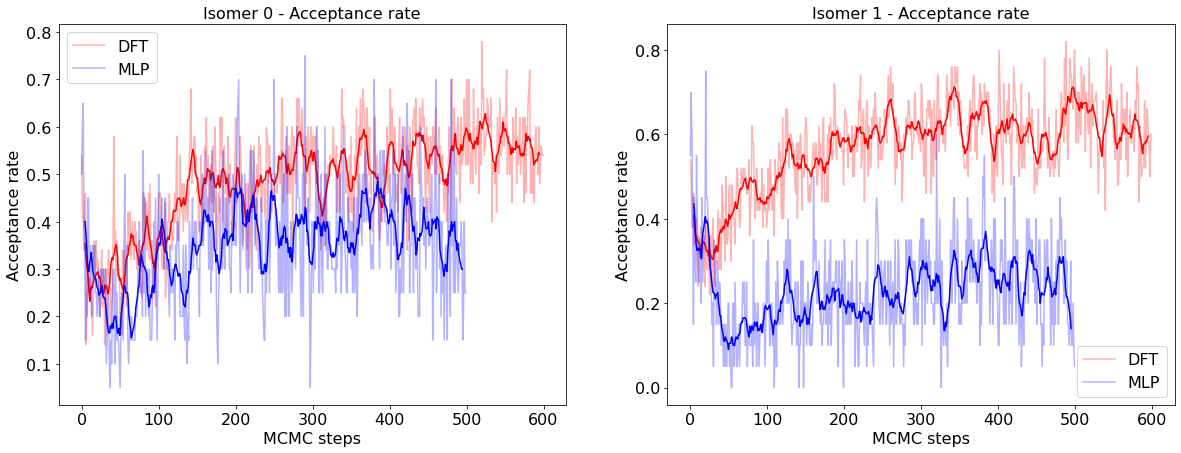

In [29]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7))

for i in range(len(accs_dft)):

    set_plot_sequential_data(accs_dft[i], ax=axs[i], color='red', label='DFT')
    set_plot_sequential_data(accs_mlp[i], ax=axs[i], color='blue', label='MLP')

    axs[i].set_xlabel('MCMC steps')
    axs[i].set_ylabel('Acceptance rate')
    axs[i].set_title(f'Isomer {i} - Acceptance rate')

    axs[i].legend()

### 1.b $\hat{R}$ test (Real centered coordinates)

In [30]:
xs_dft = [torch.cat(adaptive_mcmc['xs']).detach().numpy().transpose(1, 0, 2) for adaptive_mcmc in adaptives_mcmc_dft]
xs_mlp = [torch.cat(adaptive_mcmc['xs']).detach().numpy().transpose(1, 0, 2) for adaptive_mcmc in adaptives_mcmc_mlp]

In [31]:
rhat_dft = [R_hat(x) for x in xs_dft]
rhat_mlp = [R_hat(x) for x in xs_mlp]

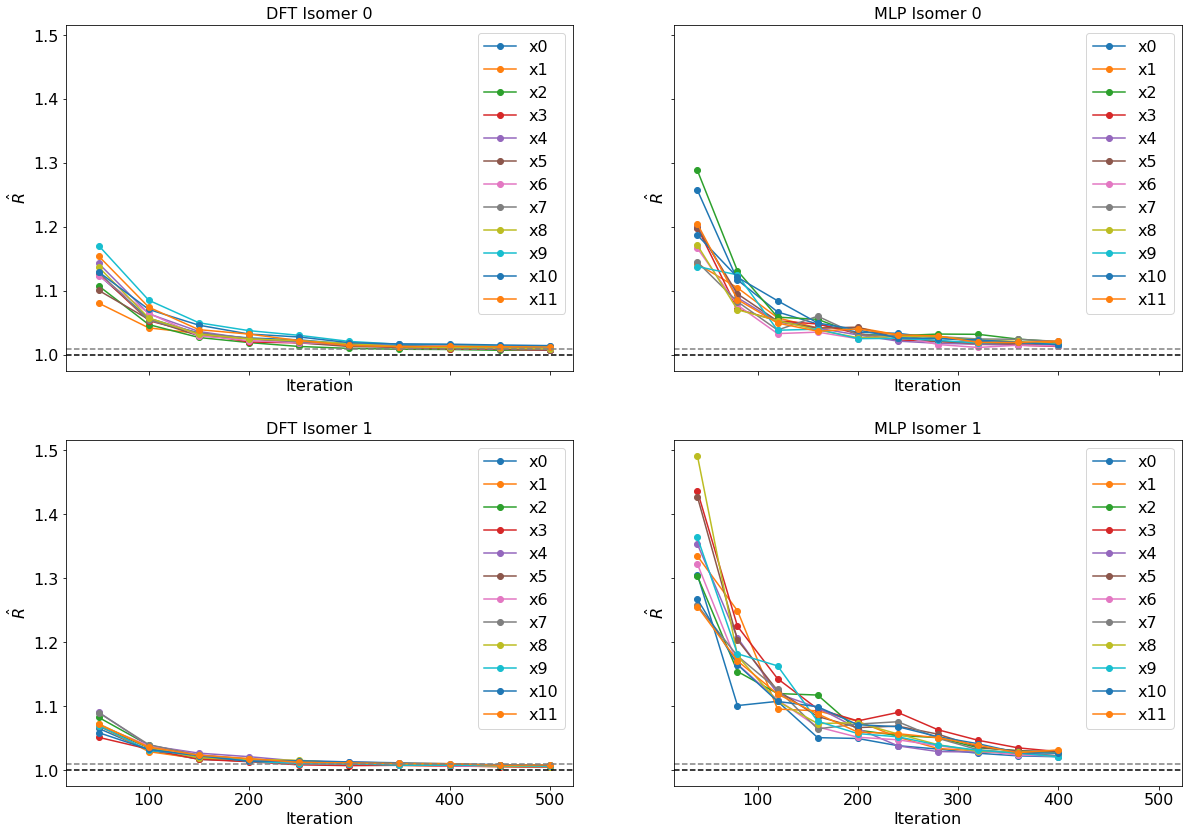

In [32]:
fig, axs = plt.subplots(2, 2, figsize=(20, 14), sharex=True, sharey=True)

for i in range(len(rhat_dft)):
    axs[i][0].plot(rhat_dft[i][1], rhat_dft[i][0], '-o',  label=rhat_dft[i][2])
    axs[i][0].axhline(1, c='k', ls='--')
    axs[i][0].axhline(1.01, c='grey', ls='--')
    axs[i][0].set_xlabel('Iteration')
    axs[i][0].set_ylabel(r'$\hat{R}$')
    axs[i][0].legend()
    axs[i][0].set_title('DFT Isomer {}'.format(i))

    axs[i][1].plot(rhat_mlp[i][1], rhat_mlp[i][0], '-o',  label=rhat_mlp[i][2])
    axs[i][1].axhline(1, c='k', ls='--')
    axs[i][1].axhline(1.01, c='grey', ls='--')
    axs[i][1].set_xlabel('Iteration')
    axs[i][1].set_ylabel(r'$\hat{R}$')
    axs[i][1].legend()
    axs[i][1].set_title('MLP Isomer {}'.format(i))

### 1.c Loss flow

In [33]:
len(adaptives_mcmc_mlp[1]['dict_flows_training'])

26

In [34]:
losses_dft = [torch.cat([adaptives_mcmc_dft[i]['dict_flows_training'][j][0]['losses'][0]
                            for j in range(len(adaptives_mcmc_dft[i]['dict_flows_training']))
                            ]) 
                            for i in range(2)]
                          
losses_mlp = [torch.cat([adaptives_mcmc_mlp[i]['dict_flows_training'][j][0]['losses'][0]
                            for j in range(len(adaptives_mcmc_mlp[i]['dict_flows_training']))
                            ])
                            for i in range(2)]

In [35]:
#len(adaptives_mcmc_dft[i]['dict_flows_training'][0][0]['losses'][0]), len(adaptives_mcmc_mlp[i]['dict_flows_training'][0][0]['losses'][0])

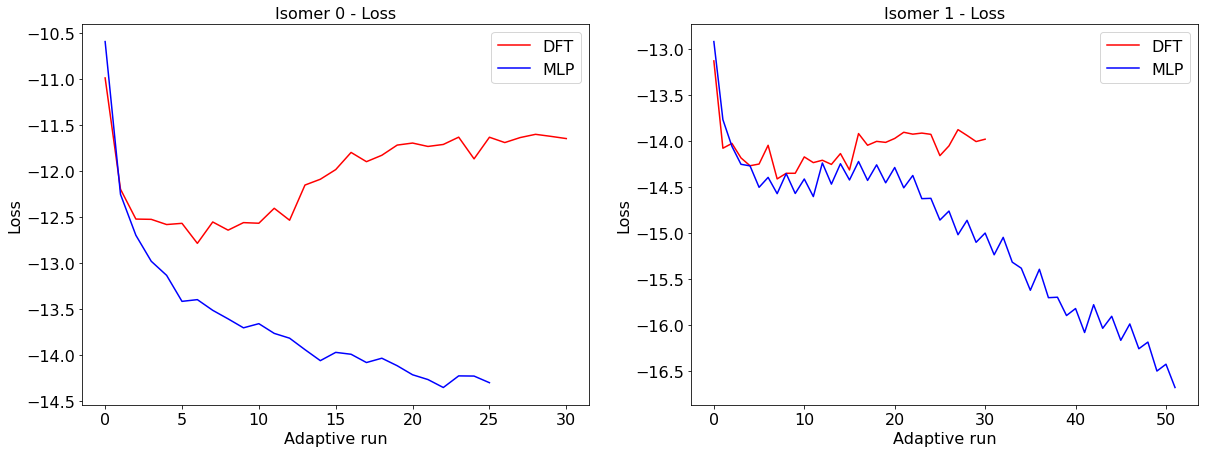

In [36]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7))

grad_steps = [200, 100]

for i in range(len(losses_dft)):
    set_plot_sequential_data(losses_dft[i][::25], ax=axs[i], color='red', label='DFT', alpha=1, avg=False)
    set_plot_sequential_data(losses_mlp[i][::grad_steps[i]], ax=axs[i], color='blue', label='MLP', alpha=1, avg=False)

    axs[i].set_xlabel('Adaptive run')
    axs[i].set_ylabel('Loss')
    axs[i].set_title(f'Isomer {i} - Loss')

    axs[i].legend()

### 1.c Loss mlp

In [37]:
losses_mlp_train = [torch.cat([torch.tensor(adaptives_mcmc_mlp[i]['dict_mlps_training'][j][0]['train_loss'])
                            for j in range(1, len(adaptives_mcmc_mlp[i]['dict_mlps_training']))
                            ])
                            for i in range(2)]

losses_mlp_test = [torch.cat([torch.tensor(adaptives_mcmc_mlp[i]['dict_mlps_training'][j][0]['test_loss'])
                            for j in range(1, len(adaptives_mcmc_mlp[i]['dict_mlps_training']))
                            ])
                            for i in range(2)]

In [38]:
losses_mlp_train

[tensor([3.1959e-05, 3.0167e-05, 2.9546e-05,  ..., 2.8340e-05, 2.8301e-05,
         2.8319e-05]),
 tensor([1.0826, 0.8035, 0.6475,  ..., 0.0013, 0.0013, 0.0013])]

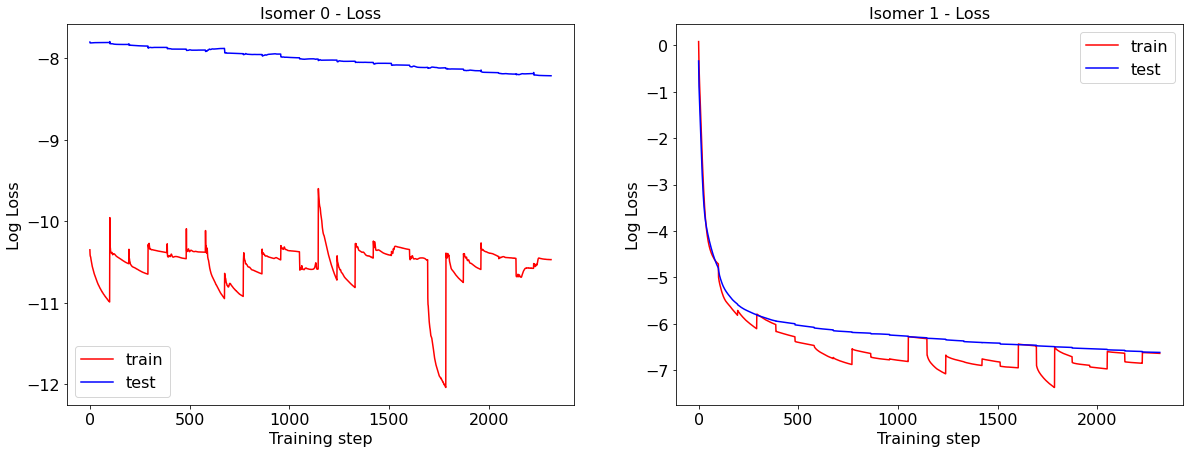

In [39]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7))

for i in range(len(losses_mlp_train)):
    set_plot_sequential_data(torch.log(losses_mlp_train[i]), ax=axs[i], color='red', label='train', alpha=1, avg=False)
    set_plot_sequential_data(torch.log(losses_mlp_test[i]), ax=axs[i], color='blue', label='test', alpha=1, avg=False)

    axs[i].set_xlabel('Training step')
    axs[i].set_ylabel('Log Loss')
    axs[i].set_title(f'Isomer {i} - Loss')

    axs[i].legend()

### 1.d Collective variables

In [52]:
coord_mapping = Coordinates_mapping()

In [53]:
xs_dft = [torch.cat(adaptive_mcmc['xs']).detach() for adaptive_mcmc in adaptives_mcmc_dft]
xs_mlp = [torch.cat(adaptive_mcmc['xs']).detach() for adaptive_mcmc in adaptives_mcmc_mlp]

In [54]:
C_dft = []
R_dft = []

for i in range(len(xs_dft)):
    
    C = []
    R = []

    for j in range(xs_dft[i].shape[0]):

        cvs = coord_mapping.get_collective_variables_from_real_centered(xs_dft[i][j], isomer=i)
        C.append(cvs[:, 0].flatten())
        R.append(cvs[:, 1].flatten())

    C_dft.append(torch.stack(C))
    R_dft.append(torch.stack(R))

In [55]:
C_mlp = []
R_mlp = []

for i in range(len(xs_mlp)):
    
    C = []
    R = []

    for j in range(xs_mlp[i].shape[0]):

        cvs = coord_mapping.get_collective_variables_from_real_centered(xs_mlp[i][j], isomer=i)
        C.append(cvs[:, 0].flatten())
        R.append(cvs[:, 1].flatten())

    C_mlp.append(torch.stack(C))
    R_mlp.append(torch.stack(R))

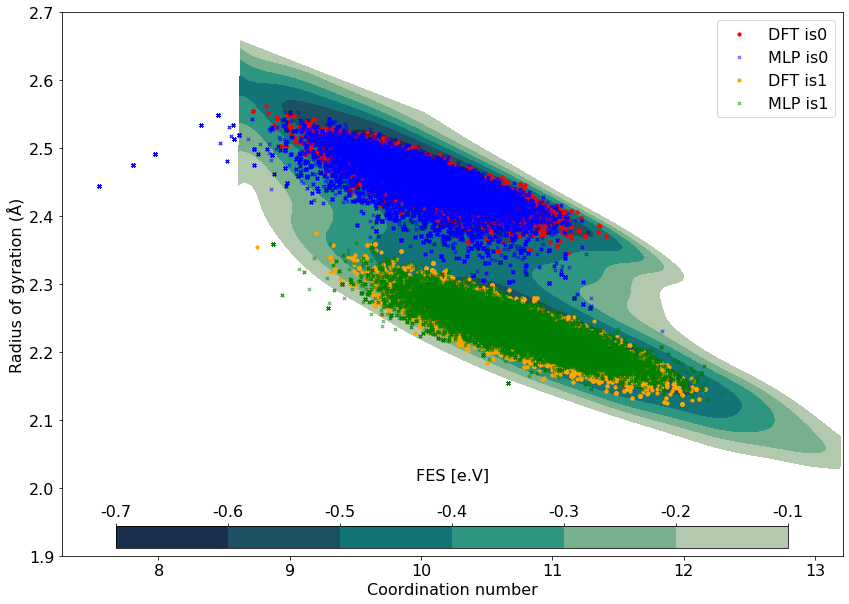

In [57]:
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

plot_energy_surface(ax=ax, fig=fig)

ax.scatter(C_dft[0].flatten().detach().numpy(), R_dft[0].flatten().detach().numpy(), s=10, c='red', label='DFT is0')
ax.scatter(C_mlp[0].flatten().detach().numpy(), R_mlp[0].flatten().detach().numpy(), s=10, c='blue', label='MLP is0', marker='x', alpha=0.5)

ax.scatter(C_dft[1].flatten().detach().numpy(), R_dft[1].flatten().detach().numpy(), s=10, c='orange', label='DFT is1')
ax.scatter(C_mlp[1].flatten().detach().numpy(), R_mlp[1].flatten().detach().numpy(), s=10, c='green', label='MLP is1', marker='x', alpha=0.5)

ax.legend()

In [60]:
N_drop=500

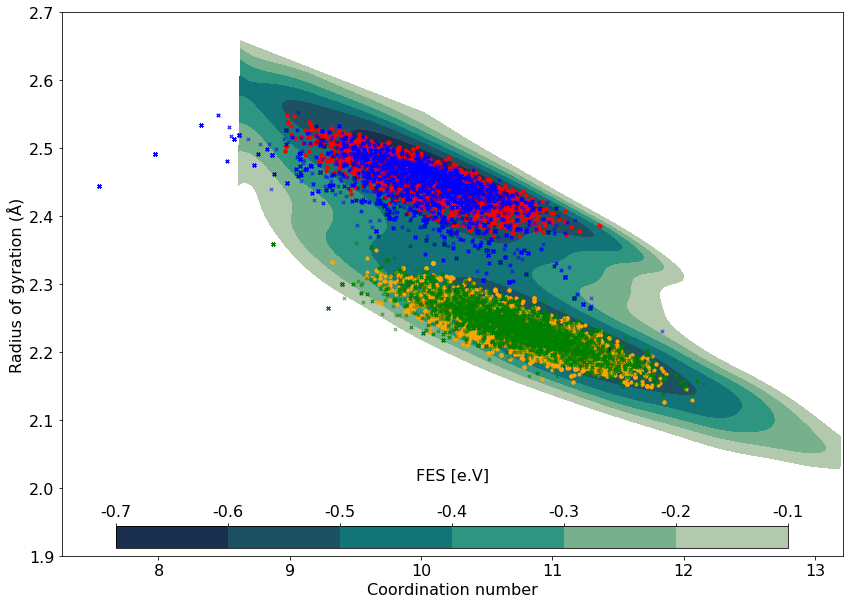

In [61]:
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

plot_energy_surface(ax=ax, fig=fig)

ax.scatter(C_dft[0][N_drop:].flatten().detach().numpy(), R_dft[0][N_drop:].flatten().detach().numpy(), s=10, c='red', label='DFT is0')
ax.scatter(C_mlp[0][N_drop:].flatten().detach().numpy(), R_mlp[0][N_drop:].flatten().detach().numpy(), s=10, c='blue', label='MLP is0', marker='x', alpha=0.5)

ax.scatter(C_dft[1][N_drop:].flatten().detach().numpy(), R_dft[1][N_drop:].flatten().detach().numpy(), s=10, c='orange', label='DFT is1')
ax.scatter(C_mlp[1][N_drop:].flatten().detach().numpy(), R_mlp[1][N_drop:].flatten().detach().numpy(), s=10, c='green', label='MLP is1', marker='x', alpha=0.5)


### 1.e Energy histograms

In [45]:
us_dft = [torch.cat(adaptive_mcmc['us']) for adaptive_mcmc in adaptives_mcmc_dft]
us_mlp = [torch.cat(adaptive_mcmc['us']) for adaptive_mcmc in adaptives_mcmc_mlp]

In [46]:
dfs = [{'DFT': us_dft[i].flatten().detach(), 
        'MLP': us_mlp[i].flatten().detach()} for i in range(2)]

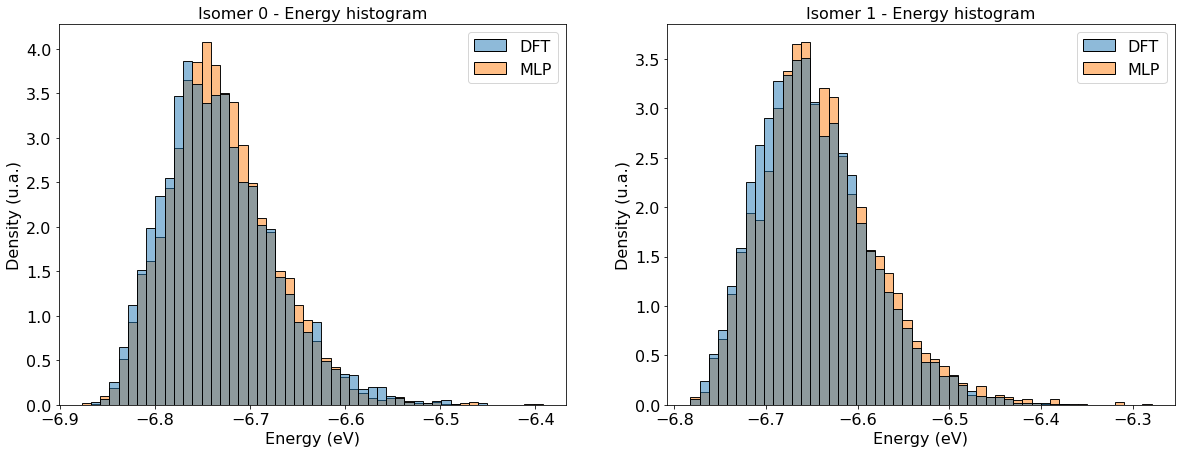

In [47]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7))

for i in range(2):
    plot_energy_histogram(dfs[i], ax=axs[i], bins=50, alpha=0.5)
    axs[i].set_title(f'Isomer {i} - Energy histogram')

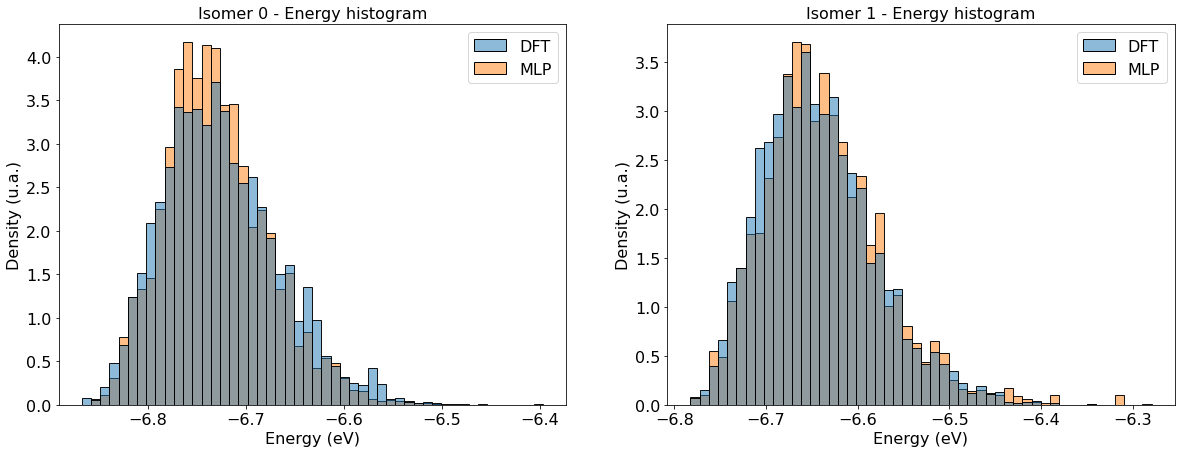

In [51]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7))

dfs_drop = [{'DFT': us_dft[i][N_drop:].detach().flatten(), 
            'MLP': us_mlp[i][N_drop:].detach().flatten()} for i in range(2)]

for i in range(len(dfs)):
    plot_energy_histogram(dfs_drop[i], ax=axs[i], bins=50, alpha=0.5)
    axs[i].set_title(f'Isomer {i} - Energy histogram')

### 1.f Free energy calculations for MLP

In [253]:
def free_energy_TFP(isomer_id, n_prop, n_trial, list_of_flows, etype, mlp_model, folder):
    
    dic_result_TFPs = {}
    dic_result_TFPs['means'] = []
    dic_result_TFPs['stds'] = []

    for r,run in enumerate(list_of_flows):
        flow = run
        log_ratio_0_TFPs = []
        log_err_0_TFPs = []

        for trial in range(n_trial):
            target_log_prob = Target_Log_Prob(energy_type=etype, 
                                    mode_label=isomer_id, 
                                    mlp_model=mlp_model, 
                                    folder=folder+'DFT_is{:d}_run_{:d}_trial_{:d}'.format(
                                        isomer_id, r, trial
                                    )
                                    ).target_log_prob

            logr_TFP_0, log_err_TFP_0 = compute_TFP(n_prop, target_log_prob, flow)
            log_ratio_0_TFPs.append(logr_TFP_0)
            log_err_0_TFPs.append(log_err_TFP_0)
        
        dic_result_TFPs[r] = (log_ratio_0_TFPs, log_err_0_TFPs)

        dic_result_TFPs['means'].append(np.array(log_ratio_0_TFPs).mean())
        dic_result_TFPs['stds'].append(np.array(log_ratio_0_TFPs).std())

    return dic_result_TFPs

In [254]:
#!ls /mnt/home/amolina/ceph/ml-dft/database/andersen/models

In [255]:
flows = [adaptives_mcmc_dft[0]['dict_flows_training'][i][0]['models'][-1] for i in range(len(adaptives_mcmc_dft[0]['dict_flows_training']))]
mlp_models = [load_pickle_file('/andersen/models/mlp_model_is{:d}.pkl'.format(i), 
                get_path()) for i in range(2)]

dict_TFP_is0 = free_energy_TFP(0, 100, 30, flows, 'mlp', mlp_models[0], folder='')
dict_TFP_is1 = free_energy_TFP(1, 100, 30, flows, 'mlp', mlp_models[1], folder='')

In [256]:
len(dict_TFP_is0.keys())

33

In [257]:
def set_plot_TFP(dict_TFP, ax, isomer_id):

    ax.set_title('isomer {:d}'.format(isomer_id))

    for r in range(len(dict_TFP.keys())-2):

        (log_ratio_0_TFPs, log_err_0_TFPs) = dict_TFP[r]
        
        ax.scatter(np.ones(len(log_ratio_0_TFPs))*r, log_ratio_0_TFPs, marker='x', alpha=0.2)
        ax.scatter(r, np.array(log_ratio_0_TFPs).mean(), c='k', marker='+')

    ax.errorbar(np.arange(len(dict_TFP['means'])), dict_TFP['means'], yerr=dict_TFP['stds'], fmt='o')
    
    ax.set_xlabel('adaptive mcmc retraining stage')
    ax.set_ylabel('log ratio by Targeted Free energy Perturbation (TFP)')


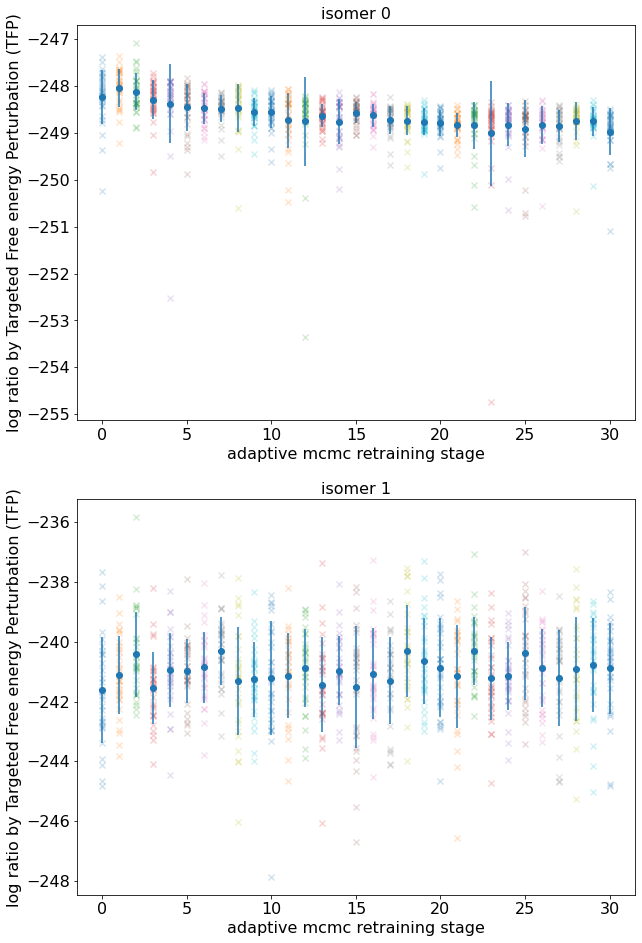

In [258]:
fig, axs = plt.subplots(2, 1, figsize=(10, 16))

set_plot_TFP(dict_TFP_is0, axs[0], 0)
set_plot_TFP(dict_TFP_is1, axs[1], 1)

In [259]:
n_prop = 8000

dic_results_BAR_mcmc = {}

for isomer_id in mode_labels:
    dic_results_BAR_mcmc[isomer_id] = {}
    dic_results_BAR_mcmc[isomer_id]['means'] = []
    dic_results_BAR_mcmc[isomer_id]['stds'] = []

    xs = torch.cat(dict_results_adaptive[isomer_id]['xs']).view(-1, 12)
    target_log_prob = lambda x: - mlps_dic[isomer_id]['model'](x) / (kb * T)
    plt.figure()
    plt.title('isomer {:d}'.format(isomer_id))
    for r,run in enumerate(dict_results_adaptive[isomer_id]['dict_flows_training']):
        flow = run[0]['models'][-1]
        log_ratio_0_BARs = []
        log_err_0_BARs = []

        for trial in range(10):
            logr_BAR_0, log_err_BAR_0 = compute_BAR(xs, target_log_prob, flow, n_prop)
            log_ratio_0_BARs.append(logr_BAR_0)
            log_err_0_BARs.append(log_err_BAR_0)
        
        plt.scatter(np.ones(len(log_ratio_0_BARs))*r, log_ratio_0_BARs, marker='x', alpha=0.2)
        plt.scatter(r, np.array(log_ratio_0_BARs).mean(), c='k', marker='+')

        dic_results_BAR_mcmc[isomer_id]['means'].append(np.array(log_ratio_0_BARs).mean())
        dic_results_BAR_mcmc[isomer_id]['stds'].append(np.array(log_ratio_0_BARs).std())
    
    plt.errorbar(np.arange(len(dic_results_BAR_mcmc[isomer_id]['means'])), dic_results_BAR_mcmc[isomer_id]['means'], yerr=dic_results_BAR_mcmc[isomer_id]['stds'], fmt='o')
   
    plt.xlabel('adaptive mcmc retraining stage')
    plt.ylabel('log ratio by BAR MCMC data')

NameError: name 'mode_labels' is not defined

## 2 MLP-mixture-MCMC with the MLP-adaptive-flows

In [176]:
from flonacomldft.sampling import run_metropolis
from flonacomldft.internal_coordinates import Coordinates_mapping
from flonacomldft.models.mixture import Mixture

In [177]:
coord_mapping = Coordinates_mapping()

In [178]:
mlp_models = [load_pickle_file('/andersen/models/mlp_model_is{:d}.pkl'.format(i), 
                get_path()) for i in range(2)]

dft_flows = [adaptives_mcmc_dft[i]['dict_flows_training'][-1][0]['models'][-1] 
             for i in range(2)]
mlp_flows = [adaptives_mcmc_mlp[i]['dict_flows_training'][15][0]['models'][-1] 
            for i in range(2)]

In [179]:
N_chains = 50

zmats_init = [load_csv_file('is{:d}_flow_test.csv'.format(i), get_path()+ '/andersen/datasets/')[:int(N_chains/2)]
for i in range(2)]

In [180]:
xs_init = []
us_init = []
isomers_init = [torch.zeros(1, int(N_chains/2)), torch.ones(1, int(N_chains/2))]

for i in range(2):
    xs_coords = coord_mapping.get_real_centered_from_internal(zmats_init[i][:, :12], isomer=i, energies=zmats_init[i][:, 12])
    xs_init.append(xs_coords[0])
    us_init.append(xs_coords[2])

#xs_init, isomers_init

xs_init = torch.cat(xs_init).reshape(-1, 12).float()
us_init = torch.cat(us_init).reshape(-1, 1).float()
isomers_init = torch.stack(isomers_init).reshape(-1, 1).float()

print(xs_init)

init_mcmc = torch.cat((xs_init, us_init, isomers_init), dim=1)

#init_mcmc

tensor([[ 3.7879e-02, -6.8475e-02, -6.5937e-03,  1.5719e-01,  5.1434e-02,
         -4.6613e-02, -1.1120e-01, -2.5445e-02,  1.7069e-02,  4.8568e-02,
         -3.5197e-01, -1.9951e-01],
        [ 2.0617e-01, -1.0393e-01,  1.3095e-01, -1.1072e-01,  2.9934e-01,
          4.1759e-02,  3.0208e-04,  2.8379e-02, -4.1253e-02, -3.3694e-02,
          4.3385e-02, -7.0481e-02],
        [ 6.4927e-02,  1.1729e-01,  2.1595e-01, -1.0195e-01,  1.1073e-01,
         -8.2213e-02, -1.4791e-01, -3.3448e-03, -6.5476e-02, -9.2989e-02,
          3.1998e-02, -9.5282e-02],
        [ 1.3588e-01, -1.4337e-01,  1.8937e-01,  2.3994e-03,  5.4911e-02,
         -4.5138e-02, -8.7164e-02, -6.4648e-02, -5.6452e-02, -7.4847e-02,
          3.3725e-01,  1.8961e-02],
        [ 1.4069e-01, -2.3071e-01,  2.5359e-01, -8.4985e-02,  9.7186e-02,
         -2.1051e-02, -9.2643e-02, -3.6724e-02, -5.6776e-02,  8.9654e-04,
          2.1200e-01, -4.7399e-02],
        [ 1.6320e-01, -5.6282e-02, -1.3442e-01,  3.8822e-02, -3.1180e-02,
      

In [181]:
flow_mixture_dft = Mixture(dft_flows, torch.tensor([0.5, 0.5]))
flow_mixture_mlp = Mixture(mlp_flows, torch.tensor([0.5, 0.5]))

In [182]:
N_steps = 600

mh_dft = run_metropolis(model=flow_mixture_dft,
    init=init_mcmc,
    n_chains=N_chains,
    n_steps=N_steps,
    dim=12,
    id_run=None,
    energy_type='mlp',
    frac_dft=0.2,
    mlp_models=mlp_models,
    mixture=True,
    T=300,
    with_tqdm=False,
    return_ratio = False,
    return_proposals = False,
    dft_folder_name = None,
    scheduler = 1,
    update_weigth = True,
    alpha=0.1,
)

step: 0 	 acc: 0.60
step: 1 	 acc: 0.42
dt, isomers shape:  1 torch.Size([2, 50])
populations window torch.Size([1, 50]) tensor(0.9800) tensor(0.0200)
current weights:  tensor([0.5000, 0.5000], requires_grad=True)
current population weights:  tensor([0.9800, 0.0200])
new weights:  tensor([0.9320, 0.0680], grad_fn=<AddBackward0>)
tensor([0.5000, 0.5000], requires_grad=True) tensor([False,  True]) tensor(False)
step: 2 	 acc: 0.34
dt, isomers shape:  2 torch.Size([3, 50])
populations window torch.Size([1, 50]) tensor(0.9800) tensor(0.0200)
current weights:  tensor([0.5000, 0.5000], requires_grad=True)
current population weights:  tensor([0.9800, 0.0200])
new weights:  tensor([0.9320, 0.0680], grad_fn=<AddBackward0>)
tensor([0.5000, 0.5000], requires_grad=True) tensor([False,  True]) tensor(False)
step: 3 	 acc: 0.42
dt, isomers shape:  3 torch.Size([4, 50])
populations window torch.Size([1, 50]) tensor(0.9800) tensor(0.0200)
current weights:  tensor([0.5000, 0.5000], requires_grad=True)


step: 105 	 acc: 0.24
dt, isomers shape:  105 torch.Size([106, 50])
populations window torch.Size([1, 50]) tensor(0.9800) tensor(0.0200)
current weights:  tensor([0.5000, 0.5000], requires_grad=True)
current population weights:  tensor([0.9800, 0.0200])
new weights:  tensor([0.9320, 0.0680], grad_fn=<AddBackward0>)
tensor([0.5000, 0.5000], requires_grad=True) tensor([False,  True]) tensor(False)
step: 106 	 acc: 0.18
dt, isomers shape:  106 torch.Size([107, 50])
populations window torch.Size([1, 50]) tensor(1.) tensor(0.)
current weights:  tensor([0.5000, 0.5000], requires_grad=True)
current population weights:  tensor([1., 0.])
new weights:  tensor([0.9500, 0.0500], grad_fn=<AddBackward0>)
tensor([0.5000, 0.5000], requires_grad=True) tensor([False,  True]) tensor(False)
step: 107 	 acc: 0.14
dt, isomers shape:  107 torch.Size([108, 50])
populations window torch.Size([1, 50]) tensor(1.) tensor(0.)
current weights:  tensor([0.5000, 0.5000], requires_grad=True)
current population weights

In [183]:
mh_mlp = run_metropolis(model=flow_mixture_mlp,
    init=init_mcmc,
    n_chains=N_chains,
    n_steps=N_steps,
    dim=12,
    id_run=None,
    energy_type='mlp',
    frac_dft=0.2,
    mlp_models=mlp_models,
    mixture=True,
    T=300,
    with_tqdm=False,
    return_ratio = False,
    return_proposals = False,
    dft_folder_name = None,
    scheduler = 1,
    update_weigth = True,
    alpha=0.1,
)

step: 0 	 acc: 0.46
step: 1 	 acc: 0.28
dt, isomers shape:  1 torch.Size([2, 50])
populations window torch.Size([1, 50]) tensor(0.8400) tensor(0.1600)
current weights:  tensor([0.5000, 0.5000], requires_grad=True)
current population weights:  tensor([0.8400, 0.1600])
new weights:  tensor([0.8060, 0.1940], grad_fn=<AddBackward0>)
tensor([0.5000, 0.5000], requires_grad=True) tensor([False,  True]) tensor(False)
step: 2 	 acc: 0.32
dt, isomers shape:  2 torch.Size([3, 50])
populations window torch.Size([1, 50]) tensor(0.9600) tensor(0.0400)
current weights:  tensor([0.5000, 0.5000], requires_grad=True)
current population weights:  tensor([0.9600, 0.0400])
new weights:  tensor([0.9140, 0.0860], grad_fn=<AddBackward0>)
tensor([0.5000, 0.5000], requires_grad=True) tensor([False,  True]) tensor(False)
step: 3 	 acc: 0.26
dt, isomers shape:  3 torch.Size([4, 50])
populations window torch.Size([1, 50]) tensor(0.9800) tensor(0.0200)
current weights:  tensor([0.5000, 0.5000], requires_grad=True)


### 2.a Acceptances MH mixture of flows

In [184]:
mhs = [mh_dft, mh_mlp]

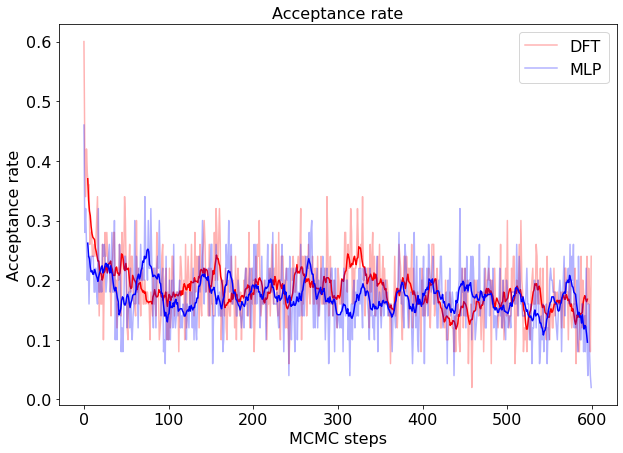

In [185]:
accs_mhs = [mh['accs'].mean(dim=1).detach() for mh in mhs]

fig, axs = plt.subplots(1, 1, figsize=(10, 7))

labels = ['DFT', 'MLP']
colors = ['red', 'blue']

for i, acc in enumerate(accs_mhs):
    set_plot_sequential_data(acc, ax=axs, color=colors[i], label=labels[i])
    axs.set_xlabel('MCMC steps')
    axs.set_ylabel('Acceptance rate')
    axs.set_title(f'Acceptance rate')

    axs.legend()

### 2.b $\hat{R}$ test

In [186]:
xs_mhs = [mh['xs'].detach().numpy().transpose(1, 0, 2) for mh in mhs]

In [187]:
rhat_mhs = [R_hat(x) for x in xs_mhs]

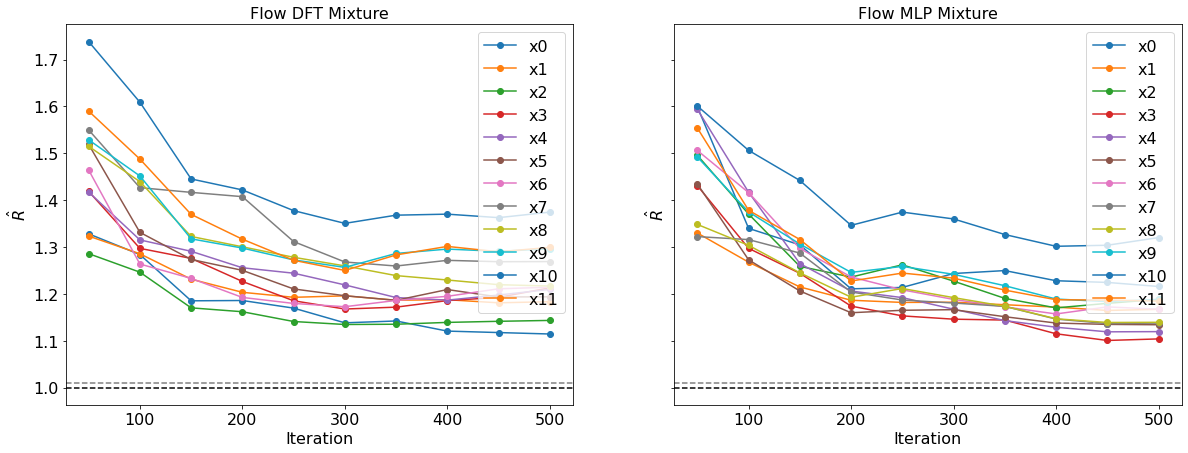

In [188]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7), sharex=True, sharey=True)

for i in range(len(rhat_mhs)):
    axs[i].plot(rhat_mhs[i][1], rhat_mhs[i][0], '-o',  label=rhat_mhs[i][2])
    axs[i].axhline(1, c='k', ls='--')
    axs[i].axhline(1.01, c='grey', ls='--')
    axs[i].set_xlabel('Iteration')
    axs[i].set_ylabel(r'$\hat{R}$')
    axs[i].legend()
    axs[i].set_title('Flow {:s} Mixture'.format(labels[i]))

### 2.c Jumps between isomers

In [189]:
isomers_mhs = [mh['isomers'] for mh in mhs]

In [216]:
jumps = [[isomers_mhs[i][:, chain].unique_consecutive() for chain in range(N_chains)]
    for i in range(2)]
jumps_counts = [[isomers_mhs[i][:, chain].unique_consecutive().shape[0] for chain in range(N_chains)]
    for i in range(2)]

In [251]:
jumps[0]

[tensor([0., 1., 0.], grad_fn=<UniqueConsecutiveBackward0>),
 tensor([0.], grad_fn=<UniqueConsecutiveBackward0>),
 tensor([0., 1., 0., 1., 0.], grad_fn=<UniqueConsecutiveBackward0>),
 tensor([0., 1., 0.], grad_fn=<UniqueConsecutiveBackward0>),
 tensor([0., 1., 0., 1., 0.], grad_fn=<UniqueConsecutiveBackward0>),
 tensor([0., 1., 0., 1., 0., 1., 0., 1., 0., 1.],
        grad_fn=<UniqueConsecutiveBackward0>),
 tensor([0.], grad_fn=<UniqueConsecutiveBackward0>),
 tensor([0., 1., 0.], grad_fn=<UniqueConsecutiveBackward0>),
 tensor([0., 1., 0., 1., 0., 1., 0.], grad_fn=<UniqueConsecutiveBackward0>),
 tensor([0.], grad_fn=<UniqueConsecutiveBackward0>),
 tensor([0., 1., 0., 1., 0.], grad_fn=<UniqueConsecutiveBackward0>),
 tensor([0.], grad_fn=<UniqueConsecutiveBackward0>),
 tensor([0.], grad_fn=<UniqueConsecutiveBackward0>),
 tensor([0.], grad_fn=<UniqueConsecutiveBackward0>),
 tensor([0., 1., 0.], grad_fn=<UniqueConsecutiveBackward0>),
 tensor([0., 1., 0., 1., 0.], grad_fn=<UniqueConsecutiveB

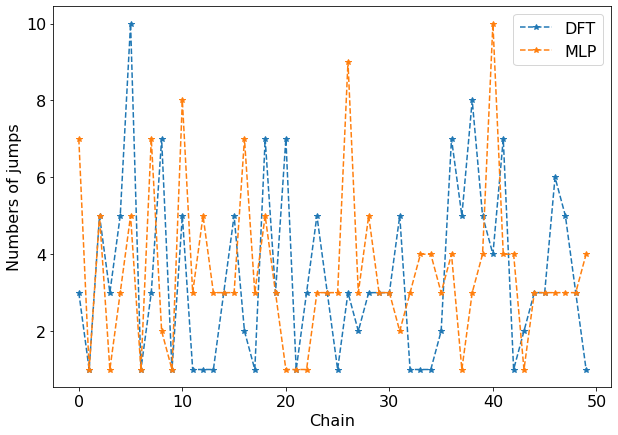

In [220]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

for i in range(2):
    ax.plot(jumps_counts[i], '--*', label=labels[i])

ax.set_xlabel('Chain')
ax.set_ylabel('Numbers of jumps')
ax.legend()